# E35 · Halo effects as Bayesian causal mediation: does social media work through search?

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Conjura's open multi-brand e-commerce MMM dataset (Anderson 2024, CC BY 4.0): one UK women's-clothing brand that spends most of its paid budget on Meta, weekly new customers, **branded-search clicks** and Google + Meta spend in the UK (165 weeks, May 2020 - Jun 2023) and the US (180 weeks, to Oct 2023) |
| **You will learn** | Why "search as a control" and "search left out" are both wrong answers to "what does Meta do?" · the potential-outcome definitions of **natural direct and indirect effects** and what identifies them · a **two-equation structural model** (mediator and outcome, adstock + saturation in both) fitted jointly in PyMC · computing NDE / NIE / total effect **from posterior draws by propagating counterfactual spend through both equations** (and why the product of coefficients is not the same thing) · the naive regressions side by side · replication in a second market · a **sensitivity analysis** for unmeasured mediator-outcome confounding, with the value at which the conclusion flips · four displays for the people who decide, including a Sankey of where 10,000 pounds of Meta goes |

Marketers call it the **halo**: someone sees an Instagram ad, does not click, and a few days
later types the brand's name into Google and buys. Last-click attribution gives that
customer to branded search. A marketing mix model (MMM) that puts branded-search clicks in
the regression "to control for demand" does something subtler but similar: it holds branded
search fixed while asking what Meta adds - and so removes exactly the customers Meta sent
through search. PyMC-Marketing's mediated / nested MMMs and Google Meridian's handling of
organic and branded search as "non-media" variables that media can move exist because of
this problem.

This notebook treats the halo as what it is, a **causal mediation** question with a
mediator (branded searches) on the path from a treatment (Meta spend) to an outcome (new
customers). It is the third notebook of a media-measurement series: E32 showed that spend
that chases demand biases every MMM, E33 built a hierarchical MMM and a budget decision.
Here the question is not how much to spend but **how Meta works**, and what that implies for
the numbers a finance team is shown.

In [1]:
import json
import logging
from pathlib import Path
from types import SimpleNamespace

import arviz as az
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
from matplotlib.patches import Ellipse, FancyBboxPatch, PathPatch
from matplotlib.path import Path as MplPath

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # a dozen fits: no sampler banner per fit
BLUE, ORANGE, AQUA, GREY, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8"
META_C, SEARCH_C = ORANGE, BLUE  # colours for "Meta direct" and "through search"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The brief and the choice of data

> *"Meta is our biggest line and finance wants it cut: our attribution says branded search
> brings in the cheapest customers. The agency's MMM, which controls for branded search,
> agrees that Meta is expensive. Our social team says half of those branded searches are
> people who saw our ads. Who is right, and how much of Meta's value runs through search?"*
> - Head of Growth, a UK women's-clothing brand

The question needs a series where branded-search clicks are recorded, Meta spend is large
and moves, and there is enough history to separate seasons from media. Scan Conjura's 143
brand x territory series (the "All Territories" rows are sums of the others):

In [2]:
data.describe("conjura_mmm")
raw = data.load("conjura_mmm")
raw["date"] = pd.to_datetime(raw["DATE_DAY"])
raw["meta"] = raw.filter(regex="^META.*_SPEND").fillna(0).sum(axis=1)
raw["google"] = raw.filter(regex="^GOOGLE.*_SPEND").fillna(0).sum(axis=1)
terr = raw[raw["TERRITORY_NAME"] != "All Territories"]
scan = terr.groupby("MMM_TIMESERIES_ID").agg(
    brand=("ORGANISATION_ID", lambda s: s.iloc[0][:6]), territory=("TERRITORY_NAME", "first"),
    vertical=("ORGANISATION_SUBVERTICAL", "first"), days=("date", "size"),
    new_cust_day=("FIRST_PURCHASES", "mean"),
    branded_clicks_day=("BRANDED_SEARCH_CLICKS", "mean"),
    branded_recorded=("BRANDED_SEARCH_CLICKS", lambda s: (s.fillna(0) > 0).mean()),
    meta_days=("meta", lambda s: (s > 0).mean()),
    meta_share_of_paid=("meta", "sum"), google_sum=("google", "sum"))
scan["meta_share_of_paid"] = scan["meta_share_of_paid"] / (scan["meta_share_of_paid"] + scan.pop("google_sum"))
ok = scan[(scan["days"] >= 700) & (scan["branded_recorded"] > 0.8) & (scan["meta_days"] > 0.85)
          & (scan["new_cust_day"] >= 20) & (scan["branded_clicks_day"] >= 50)]
ok.sort_values("new_cust_day", ascending=False).round(2)

conjura_mmm: 132,759 brand x territory x day rows (143 anonymised series from 93 e-commerce brands, 2019-2024): first-time and all purchases (orders, units, original price, discount), and spend / clicks / impressions for Google (search, shopping, PMax, display, video), Meta (Facebook, Instagram, other) and TikTok, plus organic/direct/email/referral clicks. Missing spend means the brand did not use that channel.
  source: Anderson, A. (2024), Multi-Region Marketing Mix Modelling (MMM) Dataset for Several eCommerce Brands, Conjura, figshare, doi:10.6084/m9.figshare.25314841 (CC BY 4.0).
  url:    https://ndownloader.figshare.com/files/46779652


,brand,territory,vertical,days,new_cust_day,branded_clicks_day,branded_recorded,meta_days,meta_share_of_paid
MMM_TIMESERIES_ID,,,,,,,,,
6b89cf94d2e23372be3846ed656b5e47,784d6a,UK,Women's Clothing,1389,141.78,700.98,0.85,0.91,0.78
d074408382106c56fa366d6a8351bbfa,784d6a,US,Women's Clothing,1415,84.07,170.81,1.00,0.90,0.92
a8ec66dd951d887619b18838361416d2,246b6e,UK,Music & Audio,766,53.31,121.06,0.96,0.95,0.13


Only a handful of series pass, and one brand stands out: a UK women's-clothing brand
(`784d6a`) that puts about 80% of its paid budget into Meta, records roughly 700 branded-search
clicks a day in the UK, and has almost four years of history. Its **US** series passes too,
which gives something rare in MMM work: a second market of the same brand in which to check
whether the answer replicates. (The other UK series spends only an eighth of its budget on Meta,
too little to study Meta's halo.) The UK is the main analysis, in pounds; the US is the
replication, in dollars. The two markets are fitted separately: with two markets a hierarchy
(E33) would estimate a between-market spread from two numbers, and the point here is to see
whether two independent fits agree.

Before modelling, check where the data stop being data:

In [3]:
ORG = "784d6aa3cda59f59f2400332b2420a49"
WINDOW = {"UK": ("2020-04-27", "2023-06-25", "£"), "US": ("2020-04-27", "2023-10-08", "$")}
d_all = raw[raw["ORGANISATION_ID"] == ORG]
for m in ["UK", "US"]:
    dm = d_all[d_all["TERRITORY_NAME"] == m].set_index("date").sort_index()
    last_meta = dm.index[dm["META_FACEBOOK_SPEND"].notna()].max()
    b = dm["BRANDED_SEARCH_CLICKS"]
    last_search = dm.index[b > 0.2 * b.median()].max()
    print(f"{m}: {dm.index.min().date()} -> {dm.index.max().date()}, currency {dm['CURRENCY_CODE'].iloc[0]}; "
          f"last day with Meta recorded {last_meta.date()}, with branded search above a fifth of its median {last_search.date()}")

UK: 2020-04-21 -> 2024-02-08, currency GBP; last day with Meta recorded 2023-10-09, with branded search above a fifth of its median 2023-06-30
US: 2020-04-21 -> 2024-03-05, currency USD; last day with Meta recorded 2023-10-09, with branded search above a fifth of its median 2024-03-05


Three data problems, each of which would quietly corrupt the answer:

- **The Meta feed ends on 9 October 2023** in both markets: from then on Meta spend is *missing*,
  not zero. The dataset's convention ("missing spend = channel not used") would turn this into
  a fake natural experiment in which Meta is switched off while sales carry on. The US window
  stops on 8 October 2023.
- **The UK's click data end on 30 June 2023** (all the non-paid click columns go missing, then
  return months later as single-digit counts). The UK window stops on 25 June 2023.
- **Glitch days.** On 13 US days (mostly Sundays in July-October 2023) branded-search clicks
  drop to a tenth of normal while organic-search clicks jump by about the same amount: the
  tracker filed branded searches under organic. Those days get the 15-day rolling median of
  branded clicks (2 such days in the UK).

Everything is then aggregated to Monday-Sunday weeks: budgets are planned weekly, the
day-of-week pattern is not the question, and weekly totals smooth what is left of the glitches.
Both windows start on Monday 27 April 2020, the first full week.

In [4]:
def prepare(market):
    """Weekly (Mon-Sun) series for one market, with the branded-search glitch days repaired."""
    start, end, cur = WINDOW[market]
    dm = d_all[d_all["TERRITORY_NAME"] == market].set_index("date").sort_index()
    b = dm["BRANDED_SEARCH_CLICKS"]
    med = b.rolling(15, center=True, min_periods=5).median()
    glitch = b < 0.4 * med
    dm = dm.assign(search=b.where(~glitch, med)).loc[start:end]
    w = dm[["FIRST_PURCHASES", "search", "meta", "google", "ORGANIC_SEARCH_CLICKS"]].resample("W-SUN").sum()
    return SimpleNamespace(name=market, cur=cur, weeks=w.index, T=len(w), n_glitch=int(glitch.loc[start:end].sum()),
                           y=w["FIRST_PURCHASES"].to_numpy(), B=w["search"].to_numpy(),
                           M=w["meta"].to_numpy(), G=w["google"].to_numpy(),
                           organic=w["ORGANIC_SEARCH_CLICKS"].to_numpy())


uk, us = prepare("UK"), prepare("US")
for mk in (uk, us):
    print(f"{mk.name}: {mk.T} weeks {mk.weeks[0].date()} -> {mk.weeks[-1].date()}, "
          f"{mk.n_glitch} branded-search glitch days repaired")
pd.DataFrame({mk.name: {"new customers / week": mk.y.mean(), "branded-search clicks / week": mk.B.mean(),
                        "Meta spend / week": mk.M.mean(), "Google spend / week": mk.G.mean(),
                        "Meta share of paid spend": mk.M.sum() / (mk.M.sum() + mk.G.sum())}
              for mk in (uk, us)}).round(2)

UK: 165 weeks 2020-05-03 -> 2023-06-25, 2 branded-search glitch days repaired
US: 180 weeks 2020-05-03 -> 2023-10-08, 13 branded-search glitch days repaired


,UK,US
new customers / week,1029.40,587.24
branded-search clicks / week,4960.00,1196.73
Meta spend / week,35334.19,32316.78
Google spend / week,8887.07,2287.81
Meta share of paid spend,0.80,0.93


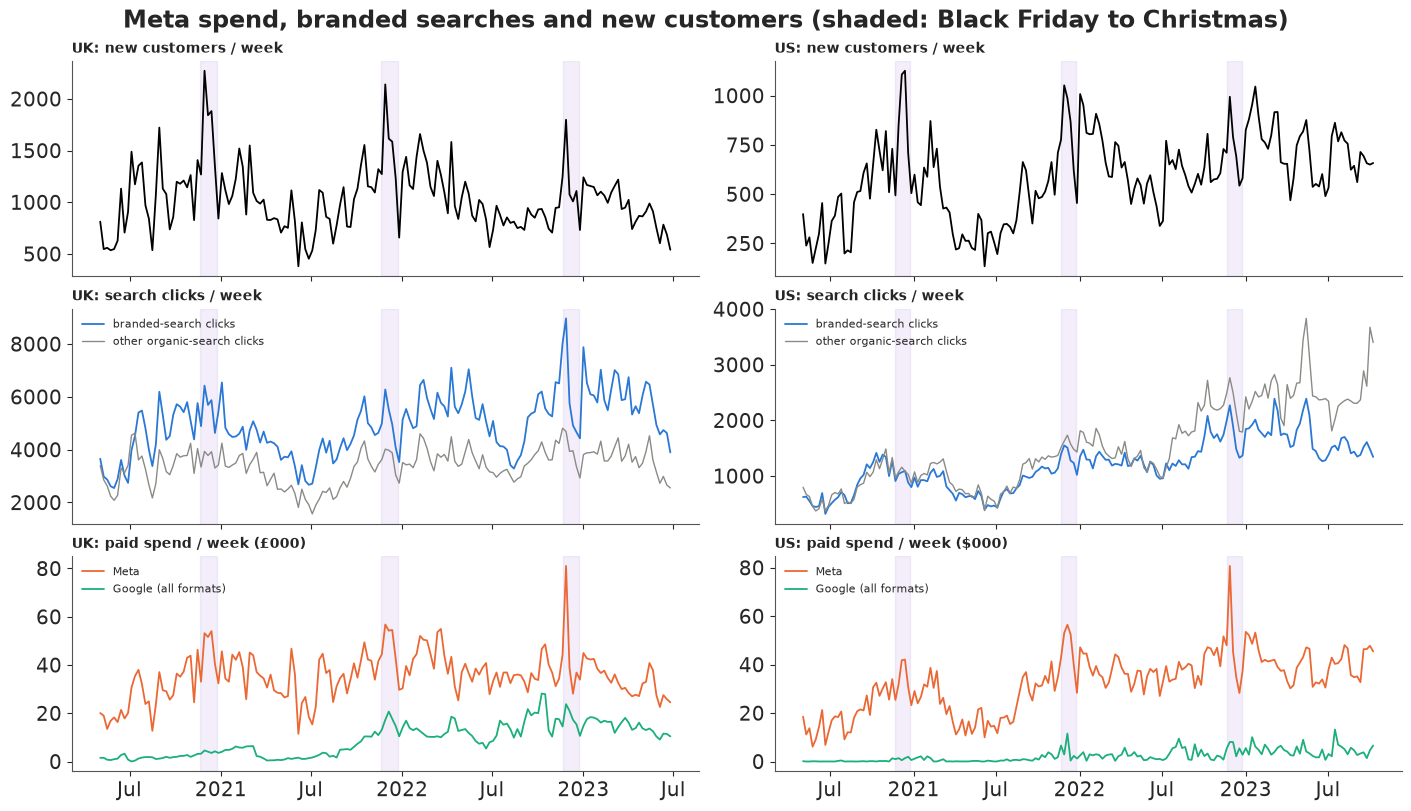

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex="col")
for j, mk in enumerate((uk, us)):
    ax = axes[0, j]
    ax.plot(mk.weeks, mk.y, color="k", lw=1.3)
    ax.set_title(f"{mk.name}: new customers / week", loc="left", fontsize=10)
    ax = axes[1, j]
    ax.plot(mk.weeks, mk.B, color=SEARCH_C, lw=1.3, label="branded-search clicks")
    ax.plot(mk.weeks, mk.organic, color=GREY, lw=1, label="other organic-search clicks")
    ax.set_title(f"{mk.name}: search clicks / week", loc="left", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax = axes[2, j]
    ax.plot(mk.weeks, mk.M / 1000, color=META_C, lw=1.3, label="Meta")
    ax.plot(mk.weeks, mk.G / 1000, color=AQUA, lw=1.3, label="Google (all formats)")
    ax.set_title(f"{mk.name}: paid spend / week ({mk.cur}000)", loc="left", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    for ax in axes[:, j]:
        for yr in (2020, 2021, 2022):
            ax.axvspan(pd.Timestamp(f"{yr}-11-20"), pd.Timestamp(f"{yr}-12-24"), color=PURPLE, alpha=0.1)
    loc = mdates.MonthLocator(bymonth=[1, 7])
    axes[2, j].xaxis.set_major_locator(loc)
    axes[2, j].xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
fig.suptitle("Meta spend, branded searches and new customers (shaded: Black Friday to Christmas)");

In [6]:
def assoc(mk):
    df = pd.DataFrame({"meta": mk.M, "search": mk.B, "cust": mk.y})
    dl = np.log(df).diff().dropna()
    pairs = [("meta", "search"), ("search", "cust"), ("meta", "cust")]
    return pd.Series({**{f"level: {a}-{b}": df[a].corr(df[b]) for a, b in pairs},
                      **{f"week-on-week change: {a}-{b}": dl[a].corr(dl[b]) for a, b in pairs}}, name=mk.name)


pd.concat([assoc(uk), assoc(us)], axis=1).round(2)

,UK,US
level: meta-search,0.63,0.85
level: search-cust,0.58,0.77
level: meta-cust,0.76,0.85
week-on-week change: meta-search,0.62,0.66
week-on-week change: search-cust,0.76,0.70
week-on-week change: meta-cust,0.77,0.84


What a modeller should see here:

- **Meta dominates paid media**: about 35,000 pounds a week in the UK (80% of paid spend) and
  32,000 dollars in the US (93%). Google is small, and in the US almost nothing.
- **Everything moves together.** Branded searches follow Meta spend (week-on-week changes
  correlate at about 0.6 in both markets), new customers follow both (0.7-0.8). In the US all
  three roughly tripled or doubled between mid-2020 and 2023, so the *levels* also share a slow
  trend. Week-to-week co-movement is what identifies each arrow below - and it is also exactly
  what a hidden common driver would produce.
- **Branded and other organic search are different series.** In the UK branded search runs
  well above generic organic search and moves with Meta; in the US organic search keeps
  climbing in 2023 while branded search levels off. Branded search is the specific signal of
  people who already know the name.
- **Black Friday** spikes new customers in both markets, but branded searches much less: people
  who buy on Black Friday arrive through deals, email and ads, not by searching the name.

## 2 · The causal question, precisely

The picture the brand's argument is about, as a causal graph:

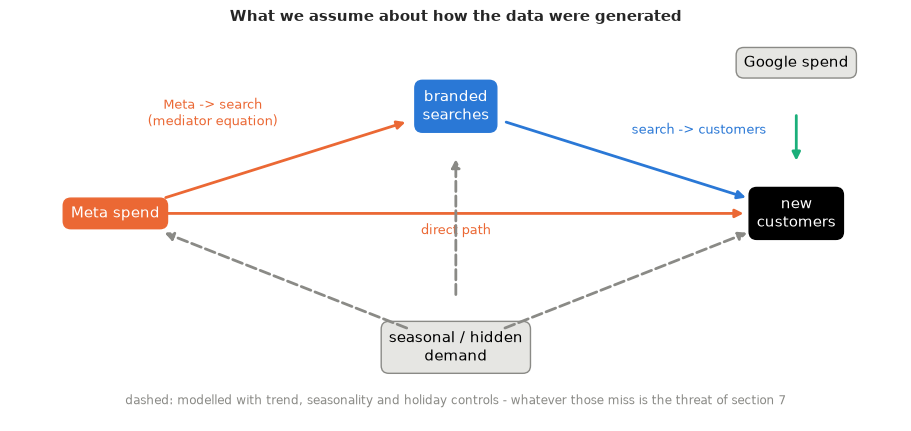

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
nodes = {"Meta spend": (0.08, 0.5), "branded\nsearches": (0.5, 0.82), "new\ncustomers": (0.92, 0.5),
         "seasonal / hidden\ndemand": (0.5, 0.1), "Google spend": (0.92, 0.95)}
for name, (x0, y0) in nodes.items():
    col = {"Meta spend": META_C, "branded\nsearches": SEARCH_C, "new\ncustomers": "k"}.get(name, GREY)
    ax.text(x0, y0, name, ha="center", va="center", fontsize=11, color="white" if col != GREY else "k",
            bbox={"boxstyle": "round,pad=0.5", "fc": col if col != GREY else "#e6e6e3", "ec": col})


def arrow(a, b, col="k", ls="-", rad=0.0, lab=None, lab_xy=None):
    ax.annotate("", xy=nodes[b], xytext=nodes[a],
                arrowprops={"arrowstyle": "-|>", "color": col, "lw": 2, "ls": ls, "shrinkA": 38, "shrinkB": 38,
                            "connectionstyle": f"arc3,rad={rad}"})
    if lab:
        ax.text(*lab_xy, lab, ha="center", va="center", fontsize=9, color=col)


arrow("Meta spend", "branded\nsearches", META_C, lab="Meta -> search\n(mediator equation)", lab_xy=(0.2, 0.8))
arrow("branded\nsearches", "new\ncustomers", SEARCH_C, lab="search -> customers", lab_xy=(0.8, 0.75))
arrow("Meta spend", "new\ncustomers", META_C, lab="direct path", lab_xy=(0.5, 0.45))
arrow("Google spend", "new\ncustomers", AQUA)
for tgt in ["branded\nsearches", "new\ncustomers", "Meta spend"]:
    arrow("seasonal / hidden\ndemand", tgt, GREY, ls="--", rad=0.0)
ax.text(0.5, -0.07, "dashed: modelled with trend, seasonality and holiday controls - "
        "whatever those miss is the threat of section 7", ha="center", fontsize=8.5, color=GREY)
ax.set(xlim=(-0.05, 1.05), ylim=(-0.12, 1.05))
ax.axis("off")
ax.set_title("What we assume about how the data were generated", fontsize=11);

Write $B(m)$ for the branded searches that a Meta spend plan $m$ would produce, and $Y(m, b)$ for
the new customers under plan $m$ if branded searches were $b$. For a change from plan $m_0$ to
plan $m_1$ (Pearl 2001; Imai, Keele & Yamamoto 2010):

- **Total effect** $\text{TE} = E[Y(m_1, B(m_1))] - E[Y(m_0, B(m_0))]$: what the budget change does.
- **Natural direct effect** $\text{NDE} = E[Y(m_1, B(m_0))] - E[Y(m_0, B(m_0))]$: change Meta, but
  hold branded searches at the level they would *naturally* have had under the old plan.
- **Natural indirect effect** $\text{NIE} = E[Y(m_1, B(m_1))] - E[Y(m_1, B(m_0))]$: keep the new
  plan, and move only the searches, from their old-plan to their new-plan level. This is the halo.

By construction $\text{TE} = \text{NDE} + \text{NIE}$. The cross-world term $Y(m_1, B(m_0))$ is
never observed; it is identified (given the controls: trend, seasonality, holidays, Google) if
(1) nothing unmeasured drives both Meta spend and searches or sales, (2) nothing unmeasured
drives both searches and sales, and (3) no driver of search-to-sales is itself moved by Meta.
Assumption (1) is E32's problem; assumption (2) is the one section 9 attacks.

The two standard shortcuts are both wrong, in opposite directions:

- **Search as a control.** Regress customers on Meta *and* branded searches. The Meta
  coefficient then answers "what does Meta add at a fixed number of searches?" - the direct
  effect. Reporting it as Meta's effect drops the NIE and hands it to branded search: last-click
  attribution in regression form. A mediator is a textbook *bad control* (Cinelli, Forney &
  Pearl 2022).
- **Search left out.** Regress customers on Meta without searches. If Meta were the only thing
  that moved searches, the Meta coefficient would target the total effect. But branded searches
  also carry demand Meta did not create (word of mouth, returning interest, press); left out,
  that demand is available to be credited to whatever moves with it - Meta. And the model
  cannot say how much of Meta runs through search, the number needed to reconcile the MMM with
  the last-click report.

## 3 · A two-equation model

One equation per arrow into a node. For week $t$, with spend in units of the market's average
week, $a_t$ the geometric adstock of Meta spend over six weeks (normalised weights $\theta^\ell$),
and Hill saturation $h(a; k) = a / (a + k)$ (so $a = 1$ at average spend):

**Mediator** (branded searches):
$B_t \sim \text{NB}(\mu^B_t, \alpha_B)$, $\;\mu^B_t = \bar B\, e^{\eta^B_t} + \pi\, \bar B\,(1 + k_B)\, h(a^B_t; k_B)$,

where $\pi$ is the **share of an average week's branded searches that Meta's average spend
generates** (at $a = 1$ the Meta term is exactly $\pi \bar B$).

**Outcome** (new customers):
$Y_t \sim \text{NB}(\mu^Y_t, \alpha_Y)$, $\;\mu^Y_t = \bar y\, e^{\eta^Y_t} + \kappa\, B_t
+ \frac{\bar M}{\text{cpc}_M}(1 + k_M)\, h(a^M_t; k_M) + \text{Google}_t$,

where $\kappa$ is **new customers per branded-search click** and $\text{cpc}_M$ the **cost per
direct Meta customer at average spend** (E33's business-unit parameterisation; Google gets the
same form). Each $\eta$ is a log baseline: intercept, linear trend, seven smooth half-year bumps
(shrunk towards zero), two yearly harmonics and three holiday indicators (Black Friday week,
the Christmas run-up, the holiday lull) - separate for each equation.

Three design choices:

- The two Meta paths get **their own carry-over and saturation**: a search can follow an ad by
  days, a click-through purchase is immediate. The data decide.
- The outcome equation uses the *observed* searches $B_t$: taken alone, it **is** the
  "search as a control" regression. What turns it into a mediation analysis is the mediator
  equation next to it, which says how Meta moves $B$.
- Fitted **jointly**, the two equations give one posterior over all parameters, so every
  posterior draw carries a coherent pair (how Meta moves searches, how searches move sales)
  from which to compute effects. (At $s = 0$ they share no parameters, so this changes little
  numerically; the sensitivity model of section 9 couples them.)

In the code the search term is written $(1 - s)\kappa\,\mu^B_t + \kappa\,(B_t - \mu^B_t)$, which is
$\kappa B_t$ at $s = 0$; $s$ is the sensitivity parameter of section 9.

In [8]:
L_AD = 6  # weeks of carry-over
HOLIDAYS = ["black_friday", "christmas_run_up", "holiday_lull"]


def lagmat(x):
    """(T,) -> (T, L_AD) matrix of x[t - l], spend before the first week held at week 1's level."""
    xs = np.concatenate([np.repeat(x[:1], L_AD - 1), x])
    return xs[np.arange(len(x))[:, None] + (L_AD - 1) - np.arange(L_AD)[None, :]]


def controls(mk):
    """Trend in years, smooth bumps (RBF, 7 centres), two yearly harmonics, holiday indicators."""
    t = np.arange(mk.T) * 7 / 365.25
    doy = mk.weeks.dayofyear.to_numpy() / 365.25
    F = np.column_stack([f(2 * np.pi * k * doy) for k in (1, 2) for f in (np.sin, np.cos)])
    R = np.exp(-0.5 * ((t[:, None] - np.linspace(0, t[-1], 7)[None]) / 0.5) ** 2)
    H = np.zeros((3, mk.T))
    for bf in pd.to_datetime(["2020-11-27", "2021-11-26", "2022-11-25"]):
        i = np.searchsorted(mk.weeks, bf)
        H[0, i] = 1
        for j in range(i + 1, mk.T):
            if mk.weeks[j].month == 12 and mk.weeks[j].day >= 24:
                break
            H[1, j] = 1
    H[2] = [(w.month == 12 and w.day >= 24) or (w.month == 1 and w.day <= 7) for w in mk.weeks]
    return t, F, R - R.mean(axis=0), H


for mk in (uk, us):
    mk.t, mk.F, mk.R, mk.H = controls(mk)
    mk.Mbar, mk.Gbar, mk.Bbar, mk.ybar = mk.M.mean(), mk.G.mean(), mk.B.mean(), mk.y.mean()
    mk.XM, mk.XG = lagmat(mk.M / mk.Mbar), lagmat(mk.G / mk.Gbar)


def hill_adstock(XL, theta, k):
    """Adstock (normalised geometric weights) then a Hill curve a / (a + k); a = 1 at average spend."""
    w = theta ** pt.arange(L_AD)
    a = pt.dot(XL, w / w.sum())
    return a / (a + k)


def build(mk, kind="joint", s=0.0):
    """kind: 'joint' (mediator + outcome), 'control' (outcome with search as a regressor),
    'omit' (outcome without search). s: sensitivity parameter of section 7 (0 = no confounding)."""
    coords = {"week": mk.weeks, "fourier": ["sin1", "cos1", "sin2", "cos2"], "holiday": HOLIDAYS,
              "bump": np.arange(mk.R.shape[1])}
    with pm.Model(coords=coords) as model:
        def baseline(prefix, loc):
            b0 = pm.Normal(f"{prefix}_b0", loc, 0.5)
            trend = pm.Normal(f"{prefix}_trend", 0.0, 0.3)
            bumps = (pm.HalfNormal(f"{prefix}_bump_sd", 0.3)
                     * pm.Normal(f"{prefix}_bump", 0.0, 1.0, dims="bump"))
            season = pm.Normal(f"{prefix}_season", 0.0, 0.3, dims="fourier")
            hol = pm.Normal(f"{prefix}_holiday", 0.0, 1.0, dims="holiday")
            return pt.exp(b0 + trend * mk.t + pt.dot(mk.R, bumps) + pt.dot(mk.F, season) + pt.dot(hol, mk.H))

        # ---- mediator: branded searches = baseline + searches caused by Meta
        if kind == "joint":
            share = pm.Beta("search_share_from_meta", 2.0, 4.0)
            th_s = pm.Beta("carryover_meta_to_search", 2.0, 3.0)
            k_s = pm.LogNormal("halfsat_meta_to_search", np.log(1.5), 0.5)
            meta_search = pm.Deterministic(
                "meta_searches", share * mk.Bbar * (1 + k_s) * hill_adstock(mk.XM, th_s, k_s), dims="week")
            muB = pm.Deterministic("muB", mk.Bbar * baseline("search", np.log(0.6)) + meta_search, dims="week")
            pm.NegativeBinomial("search", mu=muB, alpha=pm.Gamma("alpha_search", 2.0, 0.02),
                                observed=mk.B, dims="week")
        # ---- outcome: new customers = baseline + via search + Meta direct + Google
        cpc = pm.LogNormal("cpc_meta_direct", np.log(100.0), 0.8)
        th_m = pm.Beta("carryover_meta_direct", 2.0, 3.0)
        k_m = pm.LogNormal("halfsat_meta_direct", np.log(1.5), 0.5)
        direct = pm.Deterministic("meta_direct", mk.Mbar / cpc * (1 + k_m) * hill_adstock(mk.XM, th_m, k_m),
                                  dims="week")
        cpc_g = pm.LogNormal("cpc_google", np.log(100.0), 0.8)
        th_g = pm.Beta("carryover_google", 2.0, 3.0)
        k_g = pm.LogNormal("halfsat_google", np.log(1.5), 0.5)
        mu = mk.ybar * baseline("cust", np.log(0.4)) + direct + mk.Gbar / cpc_g * (1 + k_g) * hill_adstock(mk.XG, th_g, k_g)
        if kind == "joint":
            kappa = pm.Beta("cust_per_search", 2.0, 8.0)
            mu = mu + (1 - s) * kappa * muB + kappa * (mk.B - muB)
        elif kind == "control":
            mu = mu + pm.Beta("cust_per_search", 2.0, 8.0) * mk.B
        muY = pm.Deterministic("muY", pt.maximum(mu, 1.0), dims="week")
        pm.NegativeBinomial("cust", mu=muY, alpha=pm.Gamma("alpha_cust", 2.0, 0.02), observed=mk.y, dims="week")
    return model


def fit(model, label, keep=("meta_searches", "muB", "meta_direct", "muY"), **kw):
    names = [v.name for v in model.free_RVs] + [v for v in keep if v in model.named_vars]
    idata = pm.sample(model=model, random_seed=RANDOM_SEED, progressbar=False, var_names=names,
                      **{"target_accept": 0.9, **kw})
    print(f"  {label}: divergences = {int(idata.sample_stats['diverging'].sum())}, "
          f"tuning steps = {idata.posterior.attrs.get('tuning_steps')}")
    return idata


def summary(idata, names, **kw):
    """az.summary one variable at a time (safe with shared dims in ArviZ 1.3)."""
    return pd.concat([az.summary(idata, var_names=[v], **kw) for v in names])

Priors, in units a marketer can argue with:

- share of branded searches caused by Meta at average spend $\pi \sim \text{Beta}(2, 4)$: mean a
  third, anything from 5% to 75% plausible;
- new customers per branded click $\kappa \sim \text{Beta}(2, 8)$: mean 0.2, i.e. one in five
  brand-search visits is a first purchase, with room from 2 in 100 to 1 in 2;
- cost per direct Meta customer (and per Google customer) at average spend $\sim
  \text{LogNormal}(\log 100, 0.8)$: 90% between about 25 and 400 pounds;
- half-saturation $k \sim \text{LogNormal}(\log 1.5, 0.5)$ times average spend, weekly carry-over
  $\theta \sim \text{Beta}(2, 3)$, overdispersion $\alpha \sim \text{Gamma}(2, 0.02)$.

## 4 · Prior predictive check, in the stakeholder's units

prior indirect share, 5/50/95%: [ 8. 42. 82.]
prior direct cost per Meta customer at average spend, 5/50/95%: [ 27. 100. 398.]


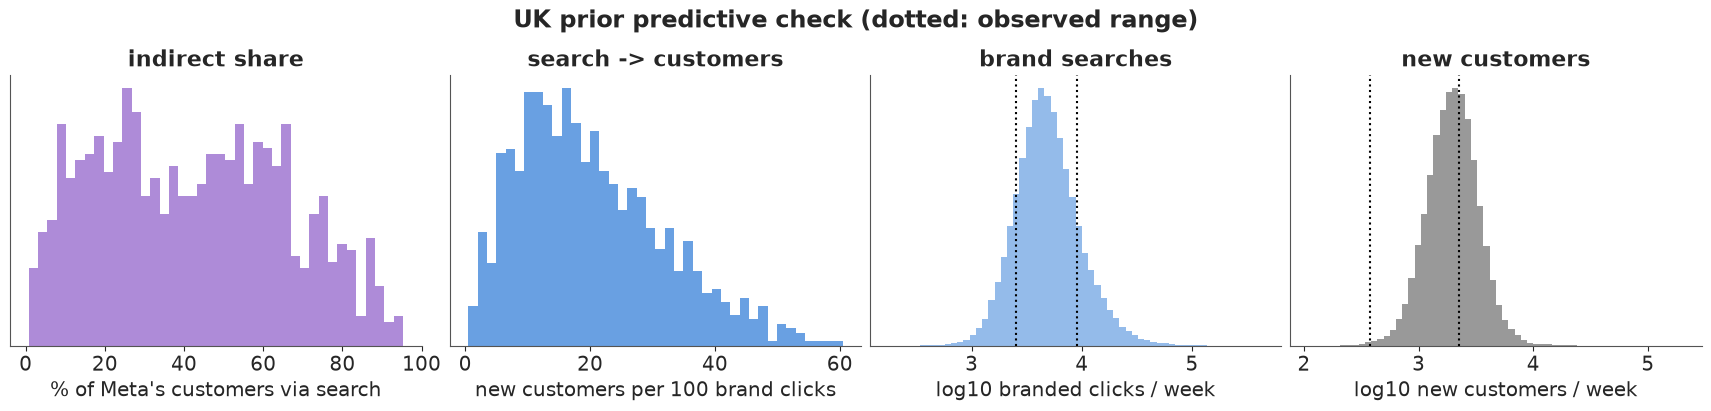

In [9]:
m_uk = build(uk)
prior = pm.sample_prior_predictive(model=m_uk, draws=1000, random_seed=RANDOM_SEED)


def draws(idata, names, group="posterior", n=1000):
    ex = az.extract(idata, group=group, var_names=list(names), num_samples=n, random_seed=RANDOM_SEED)
    if len(names) == 1:  # az.extract returns a DataArray, not a Dataset, for a single name
        return {names[0]: ex.transpose("sample", ...).to_numpy()}
    return {v: ex[v].transpose("sample", ...).to_numpy() for v in names}


P_NAMES = ["search_share_from_meta", "carryover_meta_to_search", "halfsat_meta_to_search", "cust_per_search",
           "cpc_meta_direct", "carryover_meta_direct", "halfsat_meta_direct", "muB", "meta_searches", "muY",
           "meta_direct", "alpha_search"]
pr = draws(prior, P_NAMES, group="prior")
pr_via = pr["cust_per_search"][:, None] * pr["meta_searches"]  # customers / week Meta sends via search
pr_share = pr_via.sum(1) / (pr_via.sum(1) + pr["meta_direct"].sum(1))
pr_y = az.extract(prior, group="prior_predictive", var_names=["cust"], num_samples=1000,
                  random_seed=RANDOM_SEED).transpose("sample", ...).to_numpy()
pr_B = az.extract(prior, group="prior_predictive", var_names=["search"], num_samples=1000,
                  random_seed=RANDOM_SEED).transpose("sample", ...).to_numpy()

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
axes[0].hist(100 * pr_share, bins=40, color=PURPLE, alpha=0.7)
axes[0].set(xlabel="% of Meta's customers via search", yticks=[], title="indirect share")
axes[1].hist(100 * pr["cust_per_search"], bins=40, color=SEARCH_C, alpha=0.7)
axes[1].set(xlabel="new customers per 100 brand clicks", yticks=[], title="search -> customers")
axes[2].hist(np.log10(pr_B.ravel() + 1), bins=60, color=SEARCH_C, alpha=0.5)
axes[2].axvline(np.log10(uk.B.min()), color="k", ls=":")
axes[2].axvline(np.log10(uk.B.max()), color="k", ls=":")
axes[2].set(xlabel="log10 branded clicks / week", yticks=[], title="brand searches")
axes[3].hist(np.log10(pr_y.ravel() + 1), bins=60, color="k", alpha=0.4)
axes[3].axvline(np.log10(uk.y.min()), color="k", ls=":")
axes[3].axvline(np.log10(uk.y.max()), color="k", ls=":")
axes[3].set(xlabel="log10 new customers / week", yticks=[], title="new customers")
fig.suptitle("UK prior predictive check (dotted: observed range)", y=1.1);
print("prior indirect share, 5/50/95%:", np.quantile(100 * pr_share, [0.05, 0.5, 0.95]).round(0))
print("prior direct cost per Meta customer at average spend, 5/50/95%:",
      np.quantile(pr["cpc_meta_direct"], [0.05, 0.5, 0.95]).round(0))

The prior takes no side in the argument the brief is about: the share of Meta's effect that
runs through search is spread almost evenly from under 10% to over 80% (median about 40%). Customers per
100 branded clicks sit mostly between 5 and 40. The prior predictive for brand searches puts
the observed range (dotted) in its bulk; for new customers it sits at the top of the observed
range and a little beyond - the prior's media paths are generous - but on the right order of
magnitude, with no mass on absurd values.

## 5 · Fitting the UK, diagnostics and posterior predictive checks

In [10]:
del prior
idata_uk = fit(m_uk, "UK joint model")
PARAMS = ["search_share_from_meta", "carryover_meta_to_search", "halfsat_meta_to_search", "cust_per_search",
          "cpc_meta_direct", "carryover_meta_direct", "halfsat_meta_direct", "cpc_google", "alpha_search",
          "alpha_cust", "search_holiday", "cust_holiday"]
summary(idata_uk, PARAMS, round_to=3)

  UK joint model: divergences = 0, tuning steps = 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
search_share_from_meta,0.665,0.063,0.559,0.759,1117.609,1582.804,1.004,0.002,0.001
carryover_meta_to_search,0.183,0.074,0.068,0.305,3922.770,2699.134,1.000,0.001,0.001
halfsat_meta_to_search,2.222,0.794,1.278,3.691,3499.190,3330.456,1.001,0.013,0.017
cust_per_search,0.073,0.014,0.052,0.095,1446.049,1728.149,1.002,0.000,0.000
cpc_meta_direct,81.651,16.497,61.717,109.601,1462.063,1549.847,1.001,0.450,0.813
carryover_meta_direct,0.044,0.032,0.008,0.104,4005.688,2348.795,1.001,0.000,0.001
halfsat_meta_direct,5.132,1.908,2.773,8.512,5145.514,3208.422,1.001,0.027,0.053
cpc_google,393.524,243.918,157.590,818.001,4740.187,2455.828,1.001,4.570,8.980
alpha_search,69.961,8.502,56.798,83.969,3492.592,2495.218,1.001,0.143,0.146
alpha_cust,52.093,6.475,42.388,63.012,4643.064,3589.801,1.001,0.095,0.092


In [11]:
def diag(idata):
    free = [v for v in idata.posterior.data_vars if v not in ("muB", "muY", "meta_searches", "meta_direct")]
    rh = max(float(az.rhat(idata.posterior[v]).max()) for v in free)
    es = min(float(az.ess(idata.posterior[v]).min()) for v in free)
    return f"max r_hat = {rh:.3f}, min bulk ESS = {es:.0f}, divergences = {int(idata.sample_stats['diverging'].sum())}"


print("UK joint:", diag(idata_uk))

UK joint: max r_hat = 1.005, min bulk ESS = 835, divergences = 0


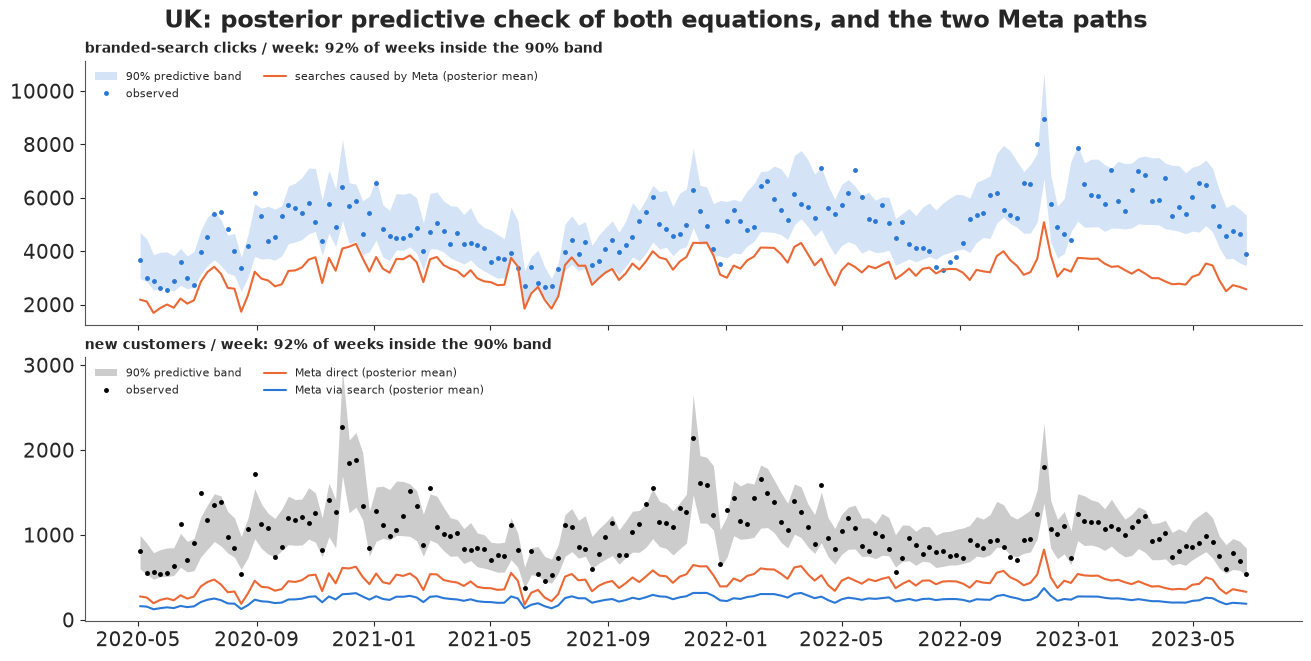

In [12]:
ppc_uk = pm.sample_posterior_predictive(idata_uk.isel(draw=slice(None, None, 4)), model=m_uk,
                                        var_names=["search", "cust"], random_seed=RANDOM_SEED, progressbar=False)


def ppc_plot(mk, ppc, idata):
    fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
    for ax, v, obs, col, lab in [(axes[0], "search", mk.B, SEARCH_C, "branded-search clicks / week"),
                                 (axes[1], "cust", mk.y, "k", "new customers / week")]:
        rep = ppc.posterior_predictive[v].stack(s=("chain", "draw")).transpose("s", ...).to_numpy()
        lo, hi = np.quantile(rep, [0.05, 0.95], axis=0)
        cover = ((obs >= lo) & (obs <= hi)).mean()
        ax.fill_between(mk.weeks, lo, hi, color=col, alpha=0.2, lw=0, label="90% predictive band")
        ax.plot(mk.weeks, obs, "o", ms=2.5, color=col, label="observed")
        ax.set_title(f"{lab}: {100 * cover:.0f}% of weeks inside the 90% band", loc="left", fontsize=10)
    ms = idata.posterior["meta_searches"].mean(("chain", "draw"))
    axes[0].plot(mk.weeks, ms, color=META_C, lw=1.5, label="searches caused by Meta (posterior mean)")
    kap = idata.posterior["cust_per_search"].mean().item()
    axes[1].plot(mk.weeks, idata.posterior["meta_direct"].mean(("chain", "draw")), color=META_C, lw=1.5,
                 label="Meta direct (posterior mean)")
    axes[1].plot(mk.weeks, kap * ms, color=SEARCH_C, lw=1.5, label="Meta via search (posterior mean)")
    for ax in axes:
        ax.legend(fontsize=8, loc="upper left", ncols=2)
    fig.suptitle(f"{mk.name}: posterior predictive check of both equations, and the two Meta paths")
    return fig


ppc_plot(uk, ppc_uk, idata_uk);

The fit is clean: no divergences, all r_hat at most 1.01, the smallest bulk ESS several
hundred. Both equations' 90% predictive bands contain about 92% of the weeks. What the
parameters say:

- **Meta -> search.** At average spend Meta generates about **two-thirds** of UK branded
  searches (share 0.56-0.76; the prior's mean was a third), with carry-over of about 0.2 a week:
  the searches follow the ads within a week or two. In the top panel, the orange line is the
  searches the model credits to Meta; the gap up to the dots is brand demand Meta did not
  create.
- **Search -> customers.** About **7 new customers per 100 branded-search clicks** (0.05-0.10).
  Most brand searchers are returning customers or browsers.
- **Meta direct.** A direct Meta customer costs about 80 pounds at average spend (60-110),
  with almost no carry-over and a nearly straight response over the spend observed.
- **Google** is poorly identified (a cost per customer in the hundreds of pounds with a very
  wide interval): its spend grew in steps rather than moving week to week, and it is a small
  line here. **Black Friday** triples the customer baseline but barely moves brand searches.

The bottom panel shows the model's claim in customers: Meta's direct path (orange) and its path
through search (blue) both run all year, the second at roughly half the size of the first.

## 6 · Natural direct and indirect effects from the posterior

**The contrast.** Plan $m_1$ is what the brand actually spent on Meta in the last 52 weeks of
data (July 2022 - June 2023); plan $m_0$ is the same weeks with Meta cut by 20%. Earlier weeks
are identical in both, so carry-over into the window is honest. The effects are "what the last
20% of Meta bought", reported **per 10,000 pounds** of that money (the 20% is about 370,000
pounds), so they read as a return on the marginal budget.

**The computation**, for every posterior draw: push both spend paths through the mediator
equation (adstock, then saturation) to get the searches Meta causes in each world, and through
the direct path; then

- NDE = direct customers under $m_1$ minus under $m_0$ (searches held at their $m_0$ level),
- NIE = $\kappa$ x (Meta-caused searches under $m_1$ minus under $m_0$) (Meta held at $m_1$),

summed over the 52 weeks. The searches Meta did not cause, and the week's random noise, are the
same in both worlds and cancel - because the outcome is linear in searches (next cell for
when it is not). The saturation and carry-over do *not* cancel: this is the nonlinear model's
answer, not a product of two coefficients.

In [13]:
def paths(p, mk, meta):
    """Weekly Meta-caused searches and Meta-direct customers for a counterfactual weekly Meta
    spend path `meta` (T,), for every posterior draw in `p`: two (draws, T) arrays."""
    XL = lagmat(meta / mk.Mbar)

    def hill(theta, k):
        w = theta[:, None] ** np.arange(L_AD)
        a = (w / w.sum(axis=1, keepdims=True)) @ XL.T
        return a / (a + k[:, None])

    k_s, k_m = p["halfsat_meta_to_search"], p["halfsat_meta_direct"]
    searches = (p["search_share_from_meta"] * mk.Bbar * (1 + k_s))[:, None] * hill(p["carryover_meta_to_search"], k_s)
    direct = (mk.Mbar / p["cpc_meta_direct"] * (1 + k_m))[:, None] * hill(p["carryover_meta_direct"], k_m)
    return searches, direct


LAST = 52  # the scenario acts on the last 52 weeks of data


def scenario(mk, cut):
    """Meta spend path with the last 52 weeks scaled by (1 - cut); earlier weeks unchanged."""
    m0 = mk.M.copy()
    m0[-LAST:] *= 1 - cut
    return m0


def effects(p, mk, s=0.0, cut=0.2):
    """NDE, NIE, TE of moving Meta from the cut plan (m0) to the actual plan (m1), summed over the
    last 52 weeks, as new customers per 10,000 of the money the cut removes. (draws,) arrays."""
    S1, D1 = paths(p, mk, mk.M)
    S0, D0 = paths(p, mk, scenario(mk, cut))
    c = (1 - s) * p["cust_per_search"]  # causal customers per extra branded search
    per10k = 10_000 / (cut * mk.M[-LAST:].sum())
    nde = (D1 - D0)[:, -LAST:].sum(axis=1) * per10k
    nie = c * (S1 - S0)[:, -LAST:].sum(axis=1) * per10k
    searches = (S1 - S0)[:, -LAST:].sum(axis=1) * per10k
    return pd.DataFrame({"NDE": nde, "NIE": nie, "TE": nde + nie, "share_indirect": nie / (nde + nie),
                         "extra_searches": searches})


p_uk = draws(idata_uk, P_NAMES[:7] + ["muB", "muY", "meta_searches", "alpha_search"])
eff_uk = effects(p_uk, uk)


def qtab(df, cols=None, qs=(0.05, 0.5, 0.95)):
    cols = cols or df.columns
    return df[cols].quantile(list(qs)).T.rename(columns=lambda q: f"q{int(100 * q):02d}")


print(f"UK, per £10,000 of the last 20% of Meta spend (last 52 weeks):")
qtab(eff_uk).round(2)

UK, per £10,000 of the last 20% of Meta spend (last 52 weeks):


,q05,q50,q95
NDE,72.84,107.18,138.49
NIE,33.30,47.90,65.62
TE,130.05,155.46,176.79
share_indirect,0.20,0.31,0.46
extra_searches,542.78,656.49,774.64


In the UK, 10,000 pounds of Meta's marginal budget buys about **155 new customers** (90%:
130-177): about **107 directly** and about **48 after a brand search** - roughly **30% of
Meta's effect runs through search** (90%: 20-46%). The same money generates about 660 extra
branded searches. Note that the two paths are each *less* certain than their sum (the direct
path's interval is wider than the total's): the data know Meta's total better than how it is
split, because a customer the model moves from one path to the other hardly changes the fit.

**The general recipe.** If the outcome were nonlinear in searches (a saturating search
response, a log link, an interaction between Meta and search), the plug-in above would be
wrong, since $E[g(B)] \neq g(E[B])$. The general algorithm (Imai, Keele & Yamamoto 2010)
simulates the mediator from its own model in each world and averages the outcome mean over those
simulated values - which is how the cross-world quantity $E[Y(m_1, B(m_0))]$ gets a number.
Here it must reproduce the plug-in answer, which makes a good unit test:

In [14]:
def effects_mc(p, mk, s=0.0, cut=0.2, n_mc=50, seed=RANDOM_SEED):
    """The general recipe: draw the mediator from its own NB distribution in each counterfactual
    world and push the draws through the outcome equation's mean. Needed whenever the outcome is
    nonlinear in the mediator; here it must reproduce `effects` up to Monte Carlo error."""
    r = np.random.default_rng(seed)
    S1, D1 = paths(p, mk, mk.M)
    S0, D0 = paths(p, mk, scenario(mk, cut))
    base_B = p["muB"] - p["meta_searches"]  # searches that would happen without Meta
    alpha = p["alpha_search"][:, None, None]

    def draw_B(S):  # NB = gamma-Poisson mixture, n_mc replicates per draw and week
        mu = (base_B + S)[:, None, -LAST:]
        return r.poisson(r.gamma(alpha, mu / alpha, size=(len(S), n_mc, LAST)))

    def outcome_mean(D, Bdraw):  # outcome mean as a function of Meta (direct) and the mediator value
        c = (1 - s) * p["cust_per_search"][:, None, None]
        return D[:, None, -LAST:] + c * Bdraw  # + terms that do not depend on Meta or the mediator

    B1, B0 = draw_B(S1), draw_B(S0)
    y11, y10, y00 = (outcome_mean(D1, B1).mean(1), outcome_mean(D1, B0).mean(1), outcome_mean(D0, B0).mean(1))
    per10k = 10_000 / (cut * mk.M[-LAST:].sum())
    return pd.DataFrame({"NDE": (y10 - y00).sum(1) * per10k, "NIE": (y11 - y10).sum(1) * per10k})


mc = effects_mc(p_uk, uk)
pd.DataFrame({"plug-in (median)": eff_uk[["NDE", "NIE"]].median(), "Monte Carlo (median)": mc.median(),
              "median |difference| per draw": (mc - eff_uk[["NDE", "NIE"]]).abs().median()}).round(2)

,plug-in (median),Monte Carlo (median),median |difference| per draw
NDE,107.18,107.18,0.0
NIE,47.90,47.90,1.3


Same medians; the per-draw differences in the indirect effect (about one customer per 10,000
pounds) are Monte Carlo noise from 50 replicates. (The direct effect agrees exactly, since both
worlds in the NDE use the same simulated searches.)

**Why not the product of coefficients?** The textbook shortcut multiplies "searches per pound"
by "customers per search". In a nonlinear model the first factor is only defined locally: take
the slope of the mediator curve at average spend and multiply by $\kappa$:

In [15]:
def product_of_coefficients(p, mk, s=0.0):
    """a * b: slope of weekly Meta-caused searches w.r.t. weekly spend at average spend (steady
    state), times customers per search - per 10,000 of spend."""
    k = p["halfsat_meta_to_search"]
    a = p["search_share_from_meta"] * mk.Bbar * k / (1 + k) / mk.Mbar
    return a * (1 - s) * p["cust_per_search"] * 10_000


rows = {}
for cut in (0.2, 0.5, 1.0):
    e = effects(p_uk, uk, cut=cut)["NIE"]
    rows[f"cut Meta by {int(100 * cut)}%"] = {"NIE per £10k, proper (median)": e.median(),
                                               "product of coefficients (median)": np.median(product_of_coefficients(p_uk, uk)),
                                               "ratio (median over draws)": np.median(product_of_coefficients(p_uk, uk) / e)}
pd.DataFrame(rows).T.round(2)

,"NIE per £10k, proper (median)",product of coefficients (median),ratio (median over draws)
cut Meta by 20%,47.9,45.42,0.95
cut Meta by 50%,53.6,45.42,0.85
cut Meta by 100%,67.2,45.42,0.68


For the 20% cut the linearisation is close (about 45 vs 48 per 10,000 pounds): a small change on a
mildly concave curve. For larger changes it goes wrong: the indirect effect per 10,000 pounds
*rises* with the size of the cut (48, 54, 67 for 20%, 50%, 100%), because a deep cut removes
the early pounds, which generate searches at a higher rate than the last ones. The product of
coefficients stays fixed, and misses about a third of the search path when Meta goes dark.
(It also ignores carry-over timing and that weekly spend is not always average, and it has no
meaning at all once the outcome is nonlinear in searches.) The honest answer to "what if we cut
Meta by X" is the propagation above, for that X.

## 7 · The two naive regressions

Fit the outcome equation alone twice, with the same priors and controls: once with branded
searches as a regressor ("search as a control"), once without ("search left out"). Each
model's Meta term is what it would report as "Meta's effect".

In [16]:
idata_uk_ctrl = fit(build(uk, "control"), "UK, search as a control")
idata_uk_omit = fit(build(uk, "omit"), "UK, search left out")
print("control:", diag(idata_uk_ctrl))
print("omit:   ", diag(idata_uk_omit))


def naive_effect(idata, mk, cut=0.2):
    """Meta effect per 10k in a single-equation model (its only Meta term)."""
    p = draws(idata, ["cpc_meta_direct", "carryover_meta_direct", "halfsat_meta_direct"])
    p.update({"search_share_from_meta": np.zeros(1000), "carryover_meta_to_search": np.full(1000, 0.5),
              "halfsat_meta_to_search": np.ones(1000)})
    _, D1 = paths(p, mk, mk.M)
    _, D0 = paths(p, mk, scenario(mk, cut))
    return (D1 - D0)[:, -LAST:].sum(axis=1) * 10_000 / (cut * mk.M[-LAST:].sum())


def compare_models(mk, idata_joint, idata_ctrl, idata_omit, p_joint, eff):
    kap_c = draws(idata_ctrl, ["cust_per_search"])["cust_per_search"]
    via_search_joint = (p_joint["cust_per_search"][:, None] * p_joint["meta_searches"]).mean(1)
    rows = {
        "search as a control": {"Meta customers per 10k": naive_effect(idata_ctrl, mk),
                                "customers credited to branded search / wk": kap_c * mk.Bbar,
                                "... of which caused by Meta / wk": np.zeros(1000)},
        "search left out": {"Meta customers per 10k": naive_effect(idata_omit, mk),
                            "customers credited to branded search / wk": np.full(1000, np.nan),
                            "... of which caused by Meta / wk": np.full(1000, np.nan)},
        "joint model: direct (NDE)": {"Meta customers per 10k": eff["NDE"].to_numpy()},
        "joint model: total (TE)": {"Meta customers per 10k": eff["TE"].to_numpy(),
                                    "customers credited to branded search / wk": p_joint["cust_per_search"] * mk.Bbar,
                                    "... of which caused by Meta / wk": via_search_joint},
    }
    out = {}
    for lab, r in rows.items():
        out[lab] = {k: (f"{np.nanmedian(v):.1f} [{np.nanquantile(v, 0.05):.1f}, {np.nanquantile(v, 0.95):.1f}]"
                        if np.isfinite(v).any() else "-") for k, v in r.items()}
        out[lab][f"cost per Meta customer ({mk.cur})"] = (
            f"{np.median(1e4 / r['Meta customers per 10k']):.0f}")
    return pd.DataFrame(out).T.fillna("-"), {k: v["Meta customers per 10k"] for k, v in rows.items()}


tab_uk, per10k_uk = compare_models(uk, idata_uk, idata_uk_ctrl, idata_uk_omit, p_uk, eff_uk)
tab_uk

  UK, search as a control: divergences = 0, tuning steps = 400


  UK, search left out: divergences = 0, tuning steps = 400
control: max r_hat = 1.007, min bulk ESS = 927, divergences = 0
omit:    max r_hat = 1.008, min bulk ESS = 577, divergences = 0


,Meta customers per 10k,customers credited to branded search / wk,... of which caused by Meta / wk,cost per Meta customer (£)
search as a control,"105.1 [74.1, 135.8]","368.6 [265.7, 471.8]","0.0 [0.0, 0.0]",95
search left out,"189.0 [164.3, 211.4]",-,-,53
joint model: direct (NDE),"107.2 [72.8, 138.5]",-,-,93
joint model: total (TE),"155.5 [130.1, 176.8]","364.1 [257.7, 474.3]","237.6 [164.8, 318.1]",64


Theory, confirmed in numbers:

- **Search as a control** reports about **105 customers per 10,000 pounds** (a cost of about
  95 pounds per Meta customer): almost exactly the joint model's *direct* effect, as it should
  be - it is the same equation. As a statement about Meta it is a third too low. It credits
  about 370 new customers a week to branded search, of which the joint model says about 240 -
  **roughly two-thirds - were sent there by Meta**.
- **Search left out** reports about **190 customers per 10,000 pounds** (about 53 pounds each),
  a fifth *above* the joint model's total of about 155 (64 pounds). Branded searches that Meta did
  not cause still bring customers, and they rise and fall with Meta over the year; with search
  out of the model, Meta absorbs part of that credit. "Leaving it out mixes paths", here with
  demand that is not Meta's at all.
- The **joint model** sits between the two, and it is the only one that can say what share of
  Meta's value arrives through search.

The agency's cost per Meta customer and the "no search" cost differ by almost a factor of two,
from the same data and the same priors - the difference is entirely which causal question each
regression answers.

## 8 · Does it replicate? The US market

Same model, same priors, fitted to the US series on its own.

In [17]:
m_us = build(us)
idata_us = fit(m_us, "US joint model")
idata_us_ctrl = fit(build(us, "control"), "US, search as a control")
idata_us_omit = fit(build(us, "omit"), "US, search left out")
for lab, idt in [("joint", idata_us), ("control", idata_us_ctrl), ("omit", idata_us_omit)]:
    print(f"US {lab}:", diag(idt))
p_us = draws(idata_us, P_NAMES[:7] + ["muB", "muY", "meta_searches", "alpha_search"])
eff_us = effects(p_us, us)
tab_us, per10k_us = compare_models(us, idata_us, idata_us_ctrl, idata_us_omit, p_us, eff_us)
tab_us

  US joint model: divergences = 0, tuning steps = 400


  US, search as a control: divergences = 0, tuning steps = 400


  US, search left out: divergences = 1, tuning steps = 400
US joint: max r_hat = 1.006, min bulk ESS = 687, divergences = 0
US control: max r_hat = 1.004, min bulk ESS = 727, divergences = 0
US omit: max r_hat = 1.003, min bulk ESS = 1051, divergences = 1


,Meta customers per 10k,customers credited to branded search / wk,... of which caused by Meta / wk,cost per Meta customer ($)
search as a control,"98.8 [77.9, 117.9]","100.9 [41.6, 169.1]","0.0 [0.0, 0.0]",101
search left out,"122.0 [106.8, 136.3]",-,-,82
joint model: direct (NDE),"98.7 [78.4, 117.4]",-,-,101
joint model: total (TE),"114.5 [99.7, 127.8]","99.5 [42.7, 163.5]","63.1 [27.0, 105.2]",87


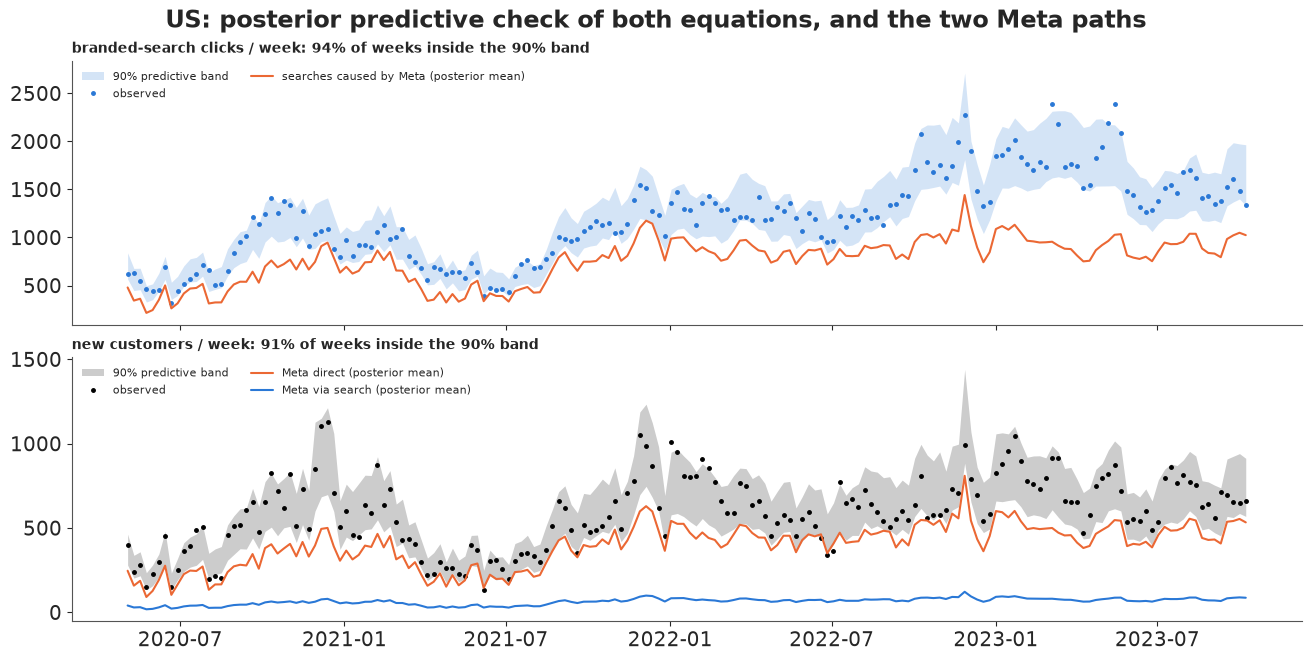

In [18]:
ppc_us = pm.sample_posterior_predictive(idata_us.isel(draw=slice(None, None, 4)), model=m_us,
                                        var_names=["search", "cust"], random_seed=RANDOM_SEED, progressbar=False)
ppc_plot(us, ppc_us, idata_us);

In [19]:
pd.concat({"UK": qtab(eff_uk), "US": qtab(eff_us)}).round(2)

q05     q50     q95
UK NDE              72.84  107.18  138.49
   NIE              33.30   47.90   65.62
   TE              130.05  155.46  176.79
   share_indirect    0.20    0.31    0.46
   extra_searches  542.78  656.49  774.64
US NDE              78.38   98.68  117.45
   NIE               6.15   15.05   25.74
   TE               99.71  114.50  127.79
   share_indirect    0.05    0.13    0.24
   extra_searches  153.24  183.78  221.15

The US fits are clean too (no divergences in the joint and control fits, one in the "search left out"
fit; r_hat at most 1.01) and the predictive bands cover 92-95% of the weeks. The *ordering*
replicates exactly: search-as-control (about 99 customers per 10,000 dollars) equals the direct
effect, the joint total is higher (about 115), and leaving search out is higher still (about
122). But the halo is **much smaller in the US**: about 15 customers per 10,000 dollars arrive
through search (6-26), about 13% of Meta's effect, against about 30% in the UK. Two reasons are visible
in the numbers: US Meta spend generates fewer brand searches (about 180 per 10,000 dollars vs
about 660 per 10,000 pounds), and the US brand is a smaller name - about 1,200 branded clicks a
week against 5,000. The halo is a property of a brand in a market, not of Meta.

One caution the US plot makes plain: in the US, Meta, branded searches and customers grew
together from 2020 to 2023, and the model gives most of both series' level to Meta (the
orange lines carry most of each series). A baseline that could bend more would give some of that growth to
the brand instead; the smooth-bump prior decides how much. That affects both paths' size more
than their split.

## 9 · Sensitivity: what if hidden demand drives both searches and sales?

The weakest assumption is (2): weeks when branded searches are *surprisingly* high are weeks
when new customers are high, and the model reads that as searches causing sales. A hidden
common driver - payday, a heatwave, a celebrity in the dress, a competitor out of stock - would
produce the same pattern. The controls take out trend, seasons and holidays; they cannot take
out week-specific demand.

The standard response (Imai, Keele & Yamamoto 2010; VanderWeele 2015) is a **sensitivity
parameter** that the data cannot estimate: fix it at a range of values, refit, and see how far
it has to go before the conclusion changes. Split the outcome's search term into the searches the
mediator equation *expects* and the *surprise*:

$$\mu^Y_t = \dots + c\,\mu^B_t + \kappa\,(B_t - \mu^B_t), \qquad c = (1 - s)\,\kappa .$$

$\kappa$ is the association between surprise searches and sales (estimated); $c$ is the causal
effect of a search, which is what the NIE uses. With no hidden confounding, $c = \kappa$
($s = 0$). The sensitivity parameter $s$ is **the share of the surprise-search / sales
association that is really hidden demand**. For readers who prefer the classic form, each $s$
implies a correlation between the mediator's unexplained weekly variation and the part of the
outcome's that the hidden cause produces (computed per draw from the fitted noise levels; top
axis of the right panel). Refit the UK model at $s$ = 0.25, 0.5, 0.75 and 0.9:

In [20]:
S_GRID = [0.0, 0.25, 0.5, 0.75, 0.9]


def implied_rho(p, mk, s):
    """Correlation between the mediator's unexplained weekly part and the part of the outcome's
    unexplained weekly variation that the hidden common cause produces, averaged over weeks."""
    u = mk.B[None] - p["muB"]  # (draws, T)
    delta = (s * p["cust_per_search"])[:, None]
    var_v = (p["muY"] + p["muY"] ** 2 / p["alpha_cust"][:, None]).mean(1, keepdims=True)
    return (delta * u.std(1, keepdims=True) / np.sqrt(delta ** 2 * u.var(1, keepdims=True) + var_v))[:, 0]


sens = {}
for s in S_GRID:
    if s == 0:
        idt = idata_uk
    else:
        idt = fit(build(uk, s=s), f"UK, s = {s}", keep=("meta_searches", "muB", "muY"))
        print("   ", diag(idt))
    p = draws(idt, P_NAMES[:7] + ["muB", "muY", "meta_searches", "alpha_search", "alpha_cust"])
    e = effects(p, uk, s=s)
    e["rho"] = implied_rho(p, uk, s)
    e["kappa"], e["c"] = p["cust_per_search"], (1 - s) * p["cust_per_search"]
    sens[s] = e
    if s != 0:
        del idt
sens_tab = pd.DataFrame({s: {"implied error correlation (median)": e["rho"].median(),
                             "customers per surprise search (kappa)": e["kappa"].median(),
                             "customers caused per search (c)": e["c"].median(),
                             "direct / £10k": e["NDE"].median(), "via search / £10k": e["NIE"].median(),
                             "total / £10k": e["TE"].median(),
                             "indirect share (median)": e["share_indirect"].median(),
                             "P(indirect share > 20%)": (e["share_indirect"] > 0.2).mean()}
                         for s, e in sens.items()}).T
sens_tab.index.name = "s"
sens_tab.round(2)

  UK, s = 0.25: divergences = 0, tuning steps = 400
    max r_hat = 1.003, min bulk ESS = 680, divergences = 0


  UK, s = 0.5: divergences = 0, tuning steps = 400
    max r_hat = 1.010, min bulk ESS = 828, divergences = 0


  UK, s = 0.75: divergences = 0, tuning steps = 400
    max r_hat = 1.006, min bulk ESS = 835, divergences = 0


  UK, s = 0.9: divergences = 0, tuning steps = 400
    max r_hat = 1.007, min bulk ESS = 883, divergences = 0


,implied error correlation (median),customers per surprise search (kappa),customers caused per search (c),direct / £10k,via search / £10k,total / £10k,indirect share (median),P(indirect share > 20%)
s,,,,,,,,
0.00,0.00,0.07,0.07,107.18,47.90,155.46,0.31,0.94
0.25,0.10,0.09,0.07,110.04,45.56,156.56,0.29,0.95
0.50,0.26,0.12,0.06,123.26,39.95,163.56,0.24,0.85
0.75,0.47,0.15,0.04,151.40,25.07,176.94,0.14,0.01
0.90,0.58,0.16,0.02,173.79,10.96,184.76,0.06,0.00


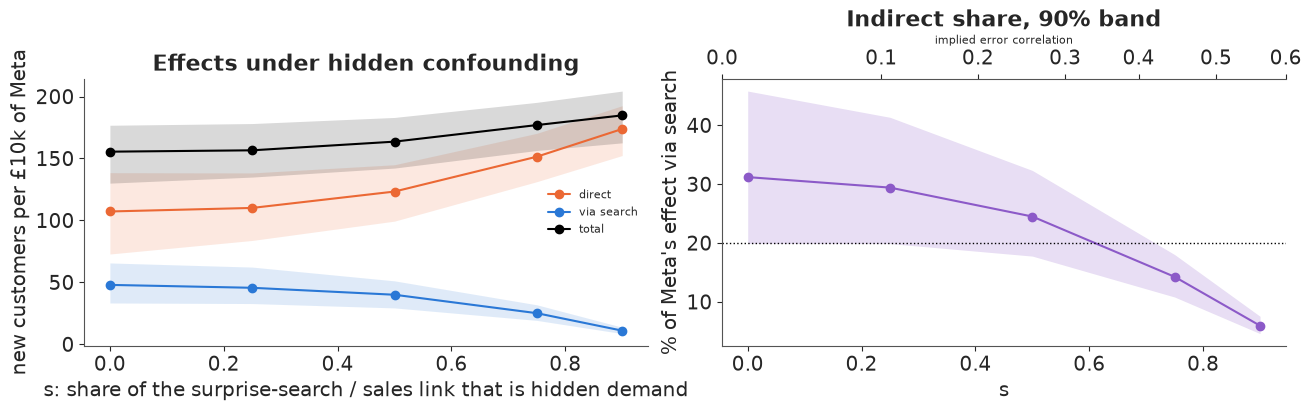

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
xs = np.array(S_GRID)
for key, col, lab in [("NDE", META_C, "direct"), ("NIE", SEARCH_C, "via search"), ("TE", "k", "total")]:
    qq = np.array([sens[s][key].quantile([0.05, 0.5, 0.95]).to_numpy() for s in S_GRID])
    axes[0].fill_between(xs, qq[:, 0], qq[:, 2], color=col, alpha=0.15, lw=0)
    axes[0].plot(xs, qq[:, 1], "o-", color=col, label=lab)
axes[0].set(xlabel="s: share of the surprise-search / sales link that is hidden demand",
            ylabel="new customers per £10k of Meta", title="Effects under hidden confounding")
axes[0].legend(fontsize=8)
qq = np.array([sens[s]["share_indirect"].quantile([0.05, 0.5, 0.95]).to_numpy() for s in S_GRID])
axes[1].fill_between(xs, 100 * qq[:, 0], 100 * qq[:, 2], color=PURPLE, alpha=0.2, lw=0)
axes[1].plot(xs, 100 * qq[:, 1], "o-", color=PURPLE)
axes[1].axhline(20, color="k", ls=":", lw=1)
axes[1].set(xlabel="s", ylabel="% of Meta's effect via search", title="Indirect share, 90% band")
sec = axes[1].secondary_xaxis("top", functions=(lambda v: np.interp(v, xs, sens_tab.iloc[:, 0]),
                                                lambda r: np.interp(r, sens_tab.iloc[:, 0], xs)))
sec.set_xlabel("implied error correlation", fontsize=8);

In [22]:
med_share = sens_tab["indirect share (median)"].to_numpy()
s_flip = float(np.interp(-0.2, -med_share, xs)) if med_share[-1] < 0.2 < med_share[0] else np.nan
rho_flip = float(np.interp(s_flip, xs, sens_tab.iloc[:, 0])) if np.isfinite(s_flip) else np.nan
print(f"the median indirect share falls below 20% at s = {s_flip:.2f} "
      f"(implied error correlation about {rho_flip:.2f})")

the median indirect share falls below 20% at s = 0.61 (implied error correlation about 0.35)


Reading the sensitivity analysis:

- **Up to s = 0.5 little changes**: the indirect share goes from about 31% to about 25%. The
  halo conclusion survives hidden demand explaining half of the surprise-search / sales link.
- **It flips at about s = 0.6** (an implied error correlation of about 0.35): beyond that the
  median share falls below one in five, and at s = 0.9 the search path is down to about 6%.
  (One in five is a threshold chosen for the story - the whole curve is printed so a reader can
  pick their own.)
- **Meta's total does not fall; it rises a little** (about 155 to 185 customers per 10,000 pounds).
  Customers the model can no longer credit to searches are partly re-credited to Meta's direct path,
  which moves with them. So the brief's practical question - is Meta undervalued by the agency's
  control model? - gets the same answer at every $s$. What hidden demand changes is *how* Meta works,
  not *whether* the control regression understates it.
- Note $\kappa$ rises with $s$: the surprise association is the part the data pin down, and the
  causal $c = (1 - s)\kappa$ is what the assumption decides.

Is $s$ above 0.6 plausible? It would mean that most weeks with more brand searches than Meta,
season, trend and holidays predict are weeks of hidden demand in which the searches themselves
did little. That cannot be settled from these data. A Meta geo holdout that records branded
searches *and* sales in the test and control regions would measure the NIE directly.

**What this analysis does not cover.** The sensitivity is about search-sales confounding only.
If Meta spend itself chases demand - budgets raised in strong weeks, Advantage+ bidding more
when conversion rates are high - then *both* Meta arrows are overstated, including the
"two-thirds of brand searches come from Meta", and nothing here corrects that. That is E32's
problem, and E32's copula approach could be added to the Meta spend equation. So: the
direct/indirect split is conditional on $s$; the total is conditional on E32's assumption.

## 10 · Showing it to the people who decide

A marketing lead or a finance partner needs four answers: where the next pounds of Meta go,
how sure we are about the split, why the agency's number differs, and how much of this rests on
an assumption. Each display shows a real posterior quantity from this notebook, in customers and
money, with no Greek letters.

### 10.1 Where £10,000 of Meta goes

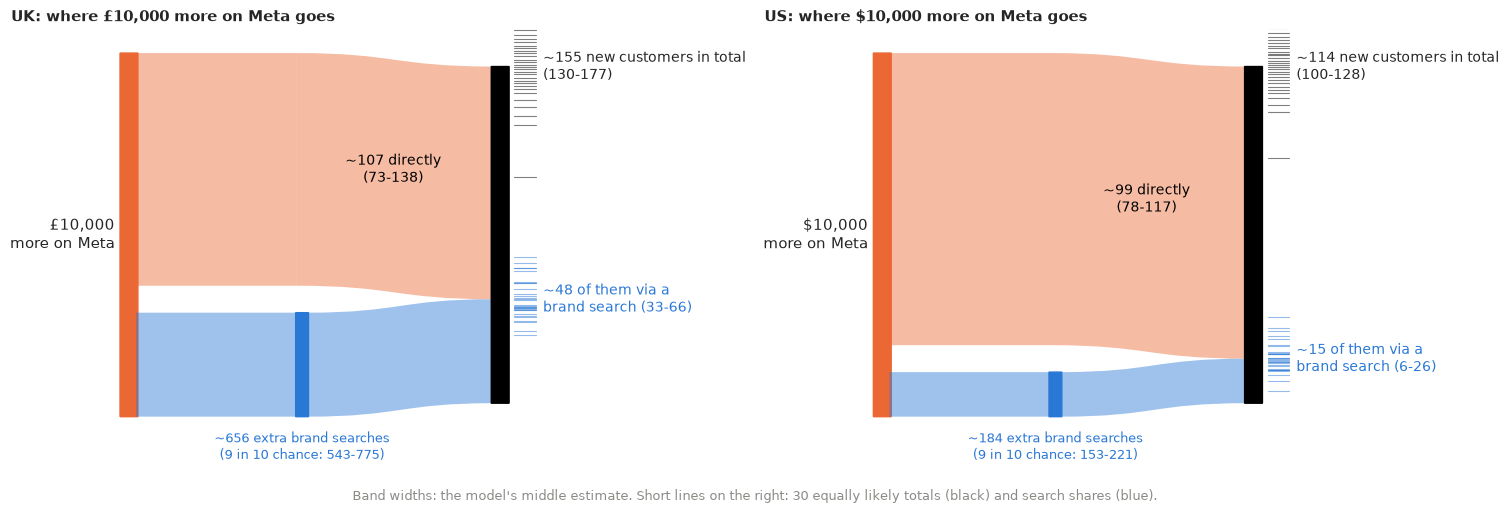

In [23]:
def ribbon(ax, x0, x1, y0a, y0b, y1a, y1b, **kw):
    """A Sankey-style band from the vertical segment [y0a, y0b] at x0 to [y1a, y1b] at x1."""
    xm = (x0 + x1) / 2
    verts = [(x0, y0a), (xm, y0a), (xm, y1a), (x1, y1a), (x1, y1b), (xm, y1b), (xm, y0b), (x0, y0b), (x0, y0a)]
    codes = [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4, MplPath.LINETO,
             MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4, MplPath.CLOSEPOLY]
    ax.add_patch(PathPatch(MplPath(verts, codes), **kw))


def sankey(ax, eff, mk, n_lines=30, title=""):
    d_med, i_med = eff["NDE"].median(), eff["NIE"].median()
    tot = d_med + i_med
    gap = 0.08 * tot
    # left node (the money), middle nodes (direct, searches), right node (customers)
    ax.add_patch(FancyBboxPatch((-0.04, 0), 0.04, tot + gap, boxstyle="round,pad=0.005", color=META_C))
    ax.text(-0.06, (tot + gap) / 2, f"{mk.cur}10,000\nmore on Meta", ha="right", va="center", fontsize=11)
    y_dir, y_srch = (gap + i_med, gap + tot), (0, i_med)
    ribbon(ax, 0, 0.45, gap + i_med, gap + tot, gap + i_med, gap + tot, color=META_C, alpha=0.45, lw=0)
    ribbon(ax, 0, 0.45, 0, i_med, 0, i_med, color=SEARCH_C, alpha=0.45, lw=0)
    ax.add_patch(FancyBboxPatch((0.45, y_srch[0]), 0.03, i_med, boxstyle="round,pad=0.003", color=SEARCH_C))
    srch = eff["extra_searches"]
    ax.text(0.465, -0.04 * tot, f"~{srch.median():,.0f} extra brand searches\n"
            f"(9 in 10 chance: {srch.quantile(0.05):,.0f}-{srch.quantile(0.95):,.0f})",
            ha="center", va="top", fontsize=9, color=SEARCH_C)
    ribbon(ax, 0.48, 1.0, 0, i_med, gap / 2 + 0, gap / 2 + i_med, color=SEARCH_C, alpha=0.45, lw=0)
    ribbon(ax, 0.45, 1.0, gap + i_med, gap + tot, gap / 2 + i_med, gap / 2 + tot, color=META_C, alpha=0.45, lw=0)
    ax.add_patch(FancyBboxPatch((1.0, gap / 2), 0.04, tot, boxstyle="round,pad=0.005", color="k"))
    # uncertainty: the right-hand edge of each flow for n_lines equally likely draws
    idx = np.linspace(0, len(eff) - 1, n_lines).astype(int)
    for j in np.argsort(eff["TE"].to_numpy())[idx]:
        ax.plot([1.06, 1.12], [gap / 2 + eff["NIE"].iloc[j]] * 2, color=SEARCH_C, lw=0.8, alpha=0.5)
        ax.plot([1.06, 1.12], [gap / 2 + eff["TE"].iloc[j]] * 2, color="k", lw=0.8, alpha=0.5)
    ax.text(1.14, gap / 2 + tot, f"~{tot:.0f} new customers in total\n({eff['TE'].quantile(0.05):.0f}-"
            f"{eff['TE'].quantile(0.95):.0f})", va="center", fontsize=10)
    ax.text(1.14, gap / 2 + i_med, f"~{i_med:.0f} of them via a\nbrand search ({eff['NIE'].quantile(0.05):.0f}-"
            f"{eff['NIE'].quantile(0.95):.0f})", va="center", fontsize=10, color=SEARCH_C)
    ax.text(0.72, gap + i_med + d_med / 2, f"~{d_med:.0f} directly\n({eff['NDE'].quantile(0.05):.0f}-"
            f"{eff['NDE'].quantile(0.95):.0f})", ha="center", va="center", fontsize=10, color="k")
    ax.set(xlim=(-0.35, 1.6), ylim=(-0.25 * tot, 1.15 * tot))
    ax.axis("off")
    ax.set_title(title, fontsize=11, loc="left")


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sankey(axes[0], eff_uk, uk, title="UK: where £10,000 more on Meta goes")
sankey(axes[1], eff_us, us, title="US: where $10,000 more on Meta goes")
fig.text(0.5, 0.01, "Band widths: the model's middle estimate. Short lines on the right: 30 equally likely "
         "totals (black) and search shares (blue).", ha="center", fontsize=9, color=GREY);

A flow diagram is the natural picture of "where does the money go": the band widths are the
model's middle estimates, in new customers per 10,000 of marginal Meta budget. Bands suggest
certainty, so the right-hand edge carries 30 short lines - 30 equally likely answers from the
posterior for the total (black) and for the part that arrived via a brand search (blue). Where
the lines spread, the model is unsure. In the UK the blue band is about a third of the total and
the blue lines scatter widely; in the US the blue band is a sliver.

### 10.2 Twenty equally likely answers: direct vs through search

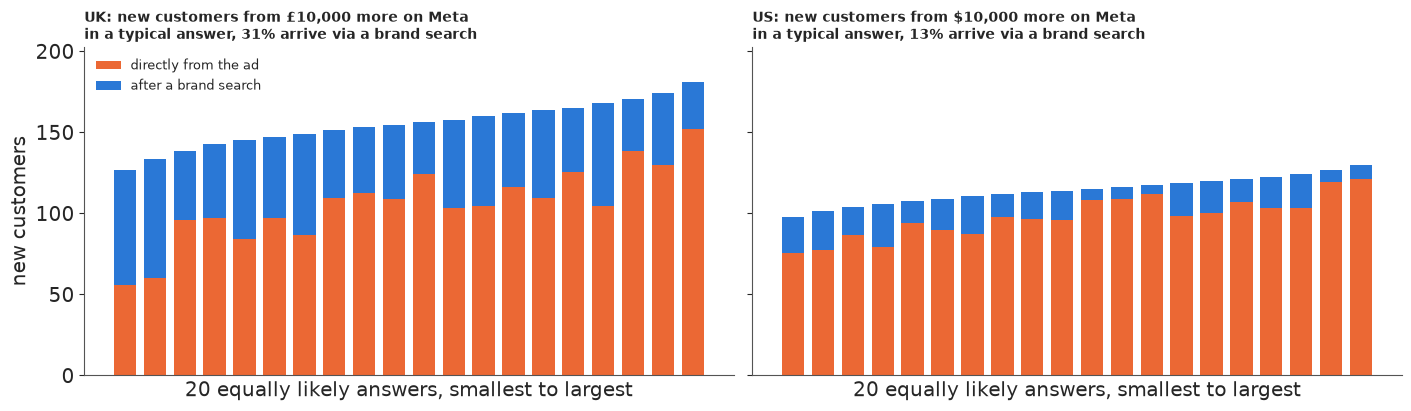

In [24]:
def stacked_futures(ax, eff, n=20, title="", ymax=None):
    order = np.argsort(eff["TE"].to_numpy())
    idx = order[((np.arange(n) + 0.5) / n * len(eff)).astype(int)]
    d, i = eff["NDE"].to_numpy()[idx], eff["NIE"].to_numpy()[idx]
    xs_ = np.arange(n)
    ax.bar(xs_, d, color=META_C, width=0.75, label="directly from the ad")
    ax.bar(xs_, i, bottom=d, color=SEARCH_C, width=0.75, label="after a brand search")
    ax.set(xticks=[], ylim=(0, ymax), xlabel="20 equally likely answers, smallest to largest")
    ax.set_title(title, fontsize=10, loc="left")
    sns.despine(ax=ax)


fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
ymax = 1.1 * max(eff_uk["TE"].quantile(0.99), eff_us["TE"].quantile(0.99))
stacked_futures(axes[0], eff_uk, title=f"UK: new customers from £10,000 more on Meta\n"
                f"in a typical answer, {100 * eff_uk['share_indirect'].median():.0f}% arrive via a brand search",
                ymax=ymax)
stacked_futures(axes[1], eff_us, title=f"US: new customers from $10,000 more on Meta\n"
                f"in a typical answer, {100 * eff_us['share_indirect'].median():.0f}% arrive via a brand search",
                ymax=ymax)
axes[0].set_ylabel("new customers")
axes[0].legend(fontsize=9, loc="upper left");

The same draws as 20 stacked bars, each one an equally likely answer (the posterior's 2.5th,
7.5th, ..., 97.5th percentile of the total, with that draw's split). Two things a band cannot
show: the answers with the *smallest* totals tend to have *larger* search parts (the direct
and search paths trade off against each other), and the split varies much more than the total.
"About 150 new customers per 10,000 pounds, of which somewhere between a fifth and a half come
through a brand search" is the honest one-line summary of the UK panel.

### 10.3 Three models, three answers: what finance would be told

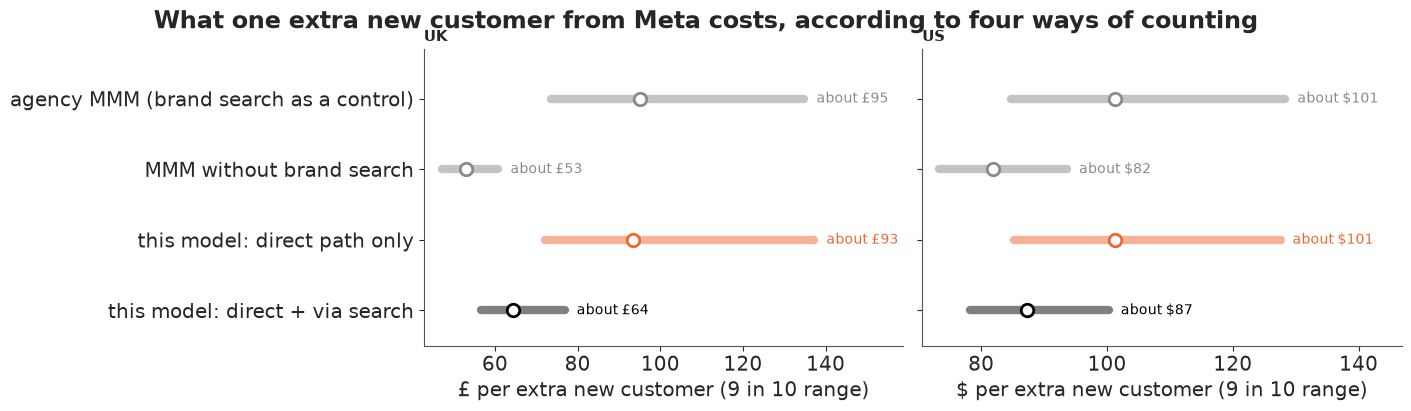

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)
labs = {"search as a control": "agency MMM (brand search as a control)",
        "search left out": "MMM without brand search",
        "joint model: direct (NDE)": "this model: direct path only",
        "joint model: total (TE)": "this model: direct + via search"}
for ax, mk, per in [(axes[0], uk, per10k_uk), (axes[1], us, per10k_us)]:
    for r, (k, lab) in enumerate(labs.items()):
        v = 1e4 / per[k]
        lo, med, hi = np.quantile(v, [0.05, 0.5, 0.95])
        col = {0: GREY, 1: GREY, 2: META_C, 3: "k"}[r]
        ax.plot([lo, hi], [r, r], color=col, lw=6, solid_capstyle="round", alpha=0.5)
        ax.plot(med, r, "o", color="white", mec=col, ms=9, mew=2)
        ax.text(hi, r, f"   about {mk.cur}{med:.0f}", fontsize=10, color=col, va="center")
    ax.set(xlabel=f"{mk.cur} per extra new customer (9 in 10 range)", yticks=range(4),
           yticklabels=list(labs.values()), xlim=(None, ax.get_xlim()[1] * 1.12))
    ax.set_title(mk.name, loc="left", fontsize=11)
    ax.set_ylim(3.5, -0.7)
fig.suptitle("What one extra new customer from Meta costs, according to four ways of counting", y=1.04);

The display for the meeting where the agency's MMM is on the table. The same data give an extra
Meta customer a price of about 95 pounds (agency model, brand search as a control), 64 pounds
(this model, both paths) or 53 pounds (no brand search in the model). The first number is the
direct path only; the last mixes in demand Meta did not create. In the US the gaps are smaller
because the search path is smaller, but in the same order.

### 10.4 If hidden seasonality were this strong...

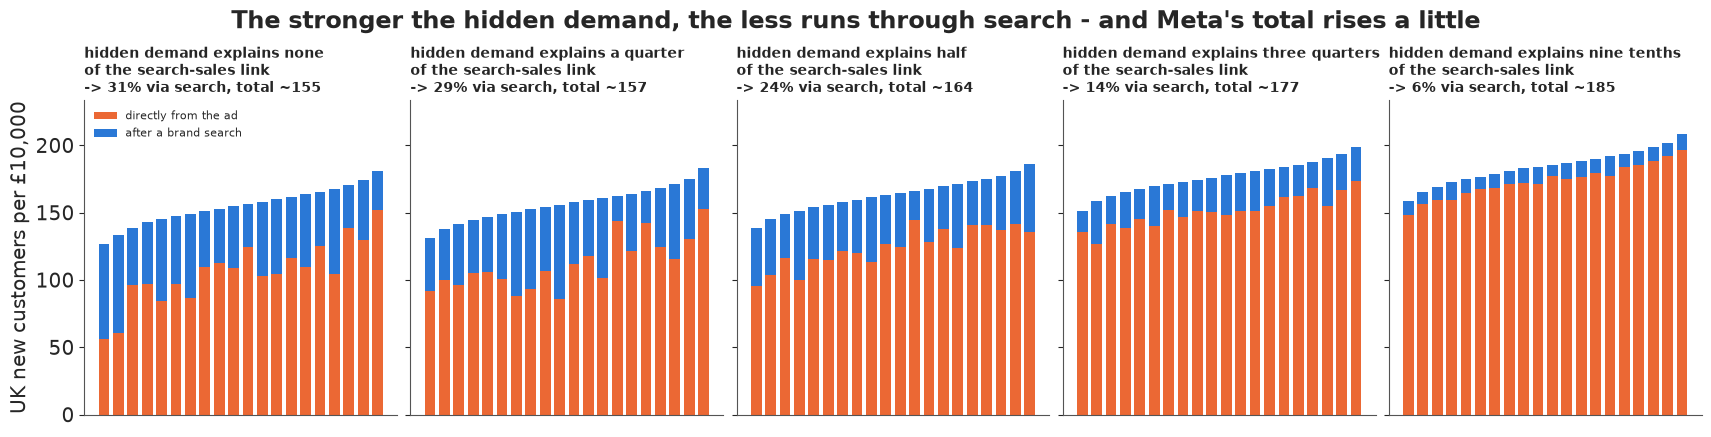

In [26]:
fig, axes = plt.subplots(1, len(S_GRID), figsize=(17, 3.9), sharey=True)
ymax = 1.1 * max(e["TE"].quantile(0.99) for e in sens.values())
plain = {0.0: "none", 0.25: "a quarter", 0.5: "half", 0.75: "three quarters", 0.9: "nine tenths"}
for ax, s in zip(axes, S_GRID):
    e = sens[s]
    sh = e["share_indirect"].median()
    stacked_futures(ax, e, ymax=ymax,
                    title=f"hidden demand explains {plain[s]}\nof the search-sales link\n"
                          f"-> {100 * sh:.0f}% via search, total ~{e['TE'].median():.0f}")
    ax.set_xlabel("")
axes[0].set_ylabel("UK new customers per £10,000")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("The stronger the hidden demand, the less runs through search - and Meta's total rises a little",
             y=1.08);

The "slider" as small multiples: each panel refits the UK model with a stronger assumption about
hidden demand (the share of the link between surprise brand-search weeks and sales that is
really a shared hidden cause). Reading left to right, the blue part shrinks; the total does not
fall. For a non-technical audience the message is: *how* Meta works through search depends on
an assumption we cannot test with these data; *that* the agency's control model undervalues
Meta does not.

### 10.5 Export for the web page

In [27]:
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sub = rng.choice(len(eff_uk), 300, replace=False)


def eff_block(eff, cur):
    return {"unit": f"new customers per {cur}10,000 of Meta (last 20% of spend, last 52 weeks)",
            **{k: {"median": float(eff[k].median()), "q05": float(eff[k].quantile(0.05)),
                   "q95": float(eff[k].quantile(0.95)), "draws": eff[k].to_numpy()[sub].round(2).tolist()}
               for k in ["NDE", "NIE", "TE", "share_indirect", "extra_searches"]}}


export = {
    "id": "E35",
    "title": "Does social media work through search? Meta's halo on branded search as causal mediation",
    "brand": "UK women's-clothing brand (anonymised, Conjura open MMM data, CC BY 4.0)",
    "markets": {mk.name: {"currency": mk.cur, "period": f"{mk.weeks[0].date()} to {mk.weeks[-1].date()}",
                          "weeks": mk.T, "meta_spend_last52": float(mk.M[-LAST:].sum()),
                          "new_customers_per_week": float(mk.ybar), "branded_searches_per_week": float(mk.Bbar)}
                for mk in (uk, us)},
    "effects": {"UK": eff_block(eff_uk, "£"), "US": eff_block(eff_us, "$")},
    "cost_per_meta_customer": {mk.name: {labs[k]: {q: float(np.quantile(1e4 / per[k], qq)) for q, qq in
                                                   [("q05", 0.05), ("median", 0.5), ("q95", 0.95)]}
                                         for k in labs}
                               for mk, per in [(uk, per10k_uk), (us, per10k_us)]},
    "sensitivity_UK": {"parameter": "s = share of the week-to-week link between surprise brand searches and "
                                    "sales that is due to hidden demand rather than search itself",
                       "grid": [{"s": s, "implied_error_correlation": float(sens[s]["rho"].median()),
                                 **{k: {q: float(sens[s][k].quantile(qq)) for q, qq in
                                        [("q05", 0.05), ("median", 0.5), ("q95", 0.95)]}
                                    for k in ["NDE", "NIE", "TE", "share_indirect"]}}
                                for s in S_GRID],
                       "s_where_median_indirect_share_falls_below_20pct": s_flip,
                       "implied_error_correlation_at_flip": rho_flip},
    "headlines": {},
}
eu, es = eff_uk, eff_us
export["headlines"] = HEADLINES = {
    "sankey_UK": (f"In the UK, £10,000 more on Meta most likely brings about {eu['TE'].median():.0f} new customers "
                  f"(9 in 10 chance: {eu['TE'].quantile(0.05):.0f}-{eu['TE'].quantile(0.95):.0f}); about "
                  f"{eu['NIE'].median():.0f} of them arrive by searching for the brand first."),
    "share": (f"Roughly {100 * eu['share_indirect'].median():.0f}% of Meta's UK effect runs through brand search "
              f"(US: {100 * es['share_indirect'].median():.0f}%) - customers that last-click reporting gives to search."),
    "naive_models": (f"A model that treats brand search as a control puts Meta's UK cost per customer at about "
                     f"£{np.median(1e4 / per10k_uk['search as a control']):.0f}; counting the search path it is about "
                     f"£{np.median(1e4 / per10k_uk['joint model: total (TE)']):.0f}."),
    "sensitivity": (f"This split assumes no hidden demand drives both brand searches and sales. If more than about "
                    f"{100 * s_flip:.0f}% of the link between surprise brand-search weeks and sales were hidden "
                    f"demand, the search path would drop below a fifth of Meta's effect; Meta's total barely changes."),
    "caveat": ("No experiment was run: these are model estimates. Meta spend that follows demand (E32) would "
               "flatter Meta's total as well; a geo holdout of Meta is the test that settles it."),
}
out = root / ".scratch" / "artifact" / "E35.json"
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, separators=(",", ":")))
print(f"wrote {out.relative_to(root)} ({out.stat().st_size / 1024:.0f} KB)")
for v in HEADLINES.values():
    print("-", v)

wrote .scratch/artifact/E35.json (24 KB)
- In the UK, £10,000 more on Meta most likely brings about 155 new customers (9 in 10 chance: 130-177); about 48 of them arrive by searching for the brand first.
- Roughly 31% of Meta's UK effect runs through brand search (US: 13%) - customers that last-click reporting gives to search.
- A model that treats brand search as a control puts Meta's UK cost per customer at about £95; counting the search path it is about £64.
- This split assumes no hidden demand drives both brand searches and sales. If more than about 61% of the link between surprise brand-search weeks and sales were hidden demand, the search path would drop below a fifth of Meta's effect; Meta's total barely changes.
- No experiment was run: these are model estimates. Meta spend that follows demand (E32) would flatter Meta's total as well; a geo holdout of Meta is the test that settles it.


## What to take away

- **A mediator is not a control.** Putting branded search in an MMM as a control removes
  Meta's effect through search and hands it to search; leaving it out lets Meta absorb demand it
  did not create. Here the two shortcuts disagree by almost a factor of two on the cost of a Meta
  customer, and the mediation model sits between them.
- **Define the effects before the model.** Natural direct and indirect effects are statements
  about counterfactual worlds; the model is the machine that computes them. Write down the
  assumptions that identify them (and which ones you can test).
- **Compute effects by propagating counterfactual spend through both equations, draw by draw.**
  The product of coefficients is a local linearisation that breaks for large budget changes,
  and is meaningless once the outcome is nonlinear in the mediator; simulate the mediator in
  each world when it is.
- **Replicate.** The UK and US of one brand agree on the ordering of the naive models and
  disagree on the size of the halo (about 30% vs 13%): the halo belongs to a brand in a market.
- **Report the sensitivity, not just the estimate.** The search share needs hidden demand to
  explain less than about 60% of the surprise-search / sales link; the undervaluation of Meta by
  the control model holds at every value tried. Spend endogeneity (E32) is a separate,
  untested assumption under both.

## Try it yourself

1. **A nonlinear search response.** Replace $\kappa B_t$ by a saturating
   $g(B) = \beta_B B / (B + k_S)$ or put the outcome on a log link. The plug-in `effects` is now
   wrong: use `effects_mc` (with more replicates) and see how far the two drift apart, and whether
   NDE + NIE still equals the TE when the two worlds interact.
2. **Pool the two markets.** Fit the UK and US jointly with partially pooled $\pi$, $\kappa$ and
   the direct cost per customer (as in E33), and a hierarchical prior on the indirect share. What
   does the US borrow from the UK - and is pooling sensible when the halo sizes are this
   different?
3. **A second mediator.** Meta can also raise direct (typed-in) visits and generic organic search.
   Add `DIRECT_CLICKS` as a second mediator (watch the 2021 tracking break in the plot of it) and
   decompose Meta's effect into path-specific effects. Then add E32's copula term for Meta spend
   to the mediator equation and see how much of "two-thirds of brand searches come from Meta"
   survives.